# Notebook 2: Baseline Models: Random Forest & XGBoost

We establish baseline performance using a **sliding window** approach with **one-hot encoding**.
Each residue is represented by its 15 neighbouring amino acids, encoded as binary vectors.

### Train/test split strategy
A critical design choice: we split at the **protein level**, not the residue level.
Splitting residues randomly would leak context as the model would see almost the entire
neighbourhood of every test residue during training, inflating accuracy by ~25 percentage points.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import collections

df = pd.read_csv("protein_sequences_ss_3.csv")
print(f"Loaded {len(df)} proteins, {sum(df['length'])} total residues")


Loaded 599 proteins, 172015 total residues


In [2]:
# Encoding 
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
aa_to_index = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def one_hot(aa):
    vec = np.zeros(20)
    if aa in aa_to_index:
        vec[aa_to_index[aa]] = 1.0
    return vec


In [3]:
# Protein-level train/test split
# We split protein IDs first, then generate residue-level windows separately
# for each split. This ensures no protein's context appears in both sets.
protein_ids = df.index.tolist()
train_ids, test_ids = train_test_split(protein_ids, test_size=0.2, random_state=42)

train_df = df.iloc[train_ids].reset_index(drop=True)
test_df  = df.iloc[test_ids].reset_index(drop=True)

print(f"Train: {len(train_df)} proteins")
print(f"Test:  {len(test_df)} proteins")


Train: 479 proteins
Test:  120 proteins


In [4]:
# Feature extraction: sliding window
WINDOW_SIZE = 15
HALF        = WINDOW_SIZE // 2

def build_features(subset_df):
    X, y = [], []
    for _, row in subset_df.iterrows():
        seq = row["sequence"]
        ss  = row["secondary_structure"]
        padded = "X" * HALF + seq + "X" * HALF
        for i in range(HALF, len(padded) - HALF):
            window = padded[i - HALF : i + HALF + 1]
            X.append(np.concatenate([one_hot(aa) for aa in window]))
            y.append(ss[i - HALF])
    return np.array(X), np.array(y)

X_train, y_train = build_features(train_df)
X_test,  y_test  = build_features(test_df)

print(f"X_train: {X_train.shape}  (samples × features)")
print(f"X_test:  {X_test.shape}")


X_train: (138806, 300)  (samples × features)
X_test:  (33209, 300)


In [5]:
# Label encoding
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label mapping: {np.str_('C'): np.int64(0), np.str_('E'): np.int64(1), np.str_('H'): np.int64(2)}


In [6]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_enc)

rf_pred = rf.predict(X_test)
print("Random Forest")
print(classification_report(y_test_enc, rf_pred, target_names=["H", "E", "C"]))


Random Forest
              precision    recall  f1-score   support

           H       0.64      0.71      0.67     12974
           E       0.67      0.33      0.44      6537
           C       0.66      0.74      0.70     13698

    accuracy                           0.65     33209
   macro avg       0.65      0.60      0.60     33209
weighted avg       0.65      0.65      0.64     33209



In [7]:
# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=6, eval_metric="mlogloss",
                    random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train_enc)

xgb_pred_enc = xgb.predict(X_test)
xgb_pred     = le.inverse_transform(xgb_pred_enc)
y_test_labels = le.inverse_transform(y_test_enc)

print("XGBoost")
print(classification_report(y_test_labels, xgb_pred))


XGBoost
              precision    recall  f1-score   support

           C       0.65      0.70      0.67     12974
           E       0.60      0.42      0.49      6537
           H       0.68      0.73      0.70     13698

    accuracy                           0.66     33209
   macro avg       0.64      0.62      0.62     33209
weighted avg       0.65      0.66      0.65     33209



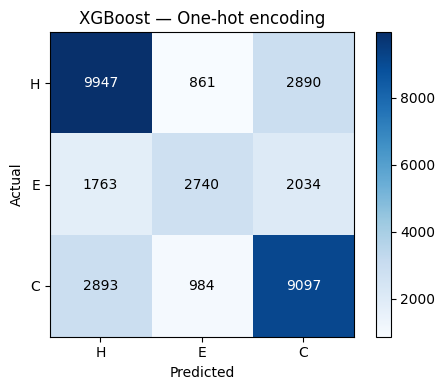


Observation: E (β-strand) recall is low (~0.42).
Strands are non-local structures — local windows cannot capture strand pairing.


In [8]:
# Confusion matrix (XGBoost) 
cm = confusion_matrix(y_test_labels, xgb_pred, labels=["H", "E", "C"])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(["H","E","C"]); ax.set_yticklabels(["H","E","C"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("XGBoost — One-hot encoding")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_baseline.png", dpi=150)
plt.show()

print("\nObservation: E (β-strand) recall is low (~0.42).")
print("Strands are non-local structures — local windows cannot capture strand pairing.")
